In [ ]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# from src.data_loader import get_team_info
# import time



In [71]:
# ============================================================
# 1. DATA LOADING
# ============================================================
df = pd.read_csv("../data/processed/clean_matches.csv")
team_df = pd.read_csv("../data/processed/team_mapping.csv")
team_map = dict(zip(team_df.team_id, team_df.team_name))
throw_comeback_team_df = pd.read_csv("../data/processed/comeback_throw_team.csv")

df["radiant_team_name"] = df["radiant_team_id"].map(team_map)
df["dire_team_name"] = df["dire_team_id"].map(team_map)

print(f"Total matches loaded: {len(df)}")
df.head()

Total matches loaded: 933


,match_id,radiant_win,start_time,duration,leagueid,radiant_score,dire_score,radiant_team_id,dire_team_id,series_id,series_type,total_kills,game_speed_categorize,radiant_team_name,dire_team_name
0,8712056091,True,2026-03-01 18:10:52,47.22,19269,32,31,8291895,9467224,1069888.0,2.0,63,Late,Tundra Esports,Aurora Gaming
1,8711970053,True,2026-03-01 17:07:03,31.98,19269,37,8,9467224,8291895,1069888.0,2.0,45,Normal,Aurora Gaming,Tundra Esports
2,8711885801,False,2026-03-01 16:08:54,28.18,19269,6,28,9467224,8291895,1069888.0,2.0,34,Fast,Aurora Gaming,Tundra Esports
3,8711768658,False,2026-03-01 14:54:59,41.80,19269,11,37,9467224,8291895,1069888.0,2.0,48,Late,Aurora Gaming,Tundra Esports
4,8711578057,True,2026-03-01 13:05:55,34.67,19269,30,15,9467224,2163,1069815.0,1.0,45,Normal,Aurora Gaming,Team Liquid


In [ ]:
# ============================================================
# 2. DATA OVERVIEW
# ============================================================

df.info()
print("\n--- Descriptive Statistics ---")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 933 entries, 0 to 932
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   match_id               933 non-null    int64  
 1   radiant_win            933 non-null    bool   
 2   start_time             933 non-null    object 
 3   duration               933 non-null    float64
 4   leagueid               933 non-null    int64  
 5   radiant_score          933 non-null    int64  
 6   dire_score             933 non-null    int64  
 7   radiant_team_id        933 non-null    int64  
 8   dire_team_id           933 non-null    int64  
 9   series_id              931 non-null    float64
 10  series_type            931 non-null    float64
 11  total_kills            933 non-null    int64  
 12  game_speed_categorize  933 non-null    object 
 13  radiant_team_name      933 non-null    object 
 14  dire_team_name         933 non-null    object 
dtypes: boo

,match_id,duration,leagueid,radiant_score,dire_score,radiant_team_id,dire_team_id,series_id,series_type,total_kills
count,9.330000e+02,933.000000,933.000000,933.000000,933.000000,9.330000e+02,9.330000e+02,9.310000e+02,931.000000,933.000000
mean,8.606859e+09,39.987610,18713.996785,23.457663,23.869239,7.658651e+06,7.382320e+06,1.046058e+06,1.092374,47.326902
std,6.551143e+07,10.775239,668.500971,10.806212,11.127241,3.186902e+06,3.406140e+06,1.490195e+04,0.863885,12.858144
min,8.510884e+09,15.750000,17419.000000,1.000000,1.000000,3.600000e+01,3.600000e+01,1.022755e+06,0.000000,14.000000
25%,8.560169e+09,32.500000,18863.000000,15.000000,14.000000,8.254145e+06,7.119388e+06,1.035897e+06,1.000000,39.000000
50%,8.600165e+09,38.350000,18988.000000,24.000000,24.000000,9.303484e+06,9.247354e+06,1.045547e+06,1.000000,46.000000
75%,8.678990e+09,45.800000,19099.000000,32.000000,32.000000,9.572001e+06,9.467224e+06,1.061831e+06,1.000000,55.000000
max,8.712056e+09,85.120000,19269.000000,53.000000,61.000000,9.989747e+06,9.989756e+06,1.069888e+06,3.000000,95.000000


In [56]:
# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================

bins = list(range(30,45))

df["duration_group"] = pd.cut(df["duration"], bins=bins)

df["duration_group"].value_counts().sort_index()

duration_group
(30, 31]    34
(31, 32]    34
(32, 33]    31
(33, 34]    47
(34, 35]    37
(35, 36]    44
(36, 37]    39
(37, 38]    45
(38, 39]    33
(39, 40]    40
(40, 41]    31
(41, 42]    30
(42, 43]    40
(43, 44]    24
Name: count, dtype: int64

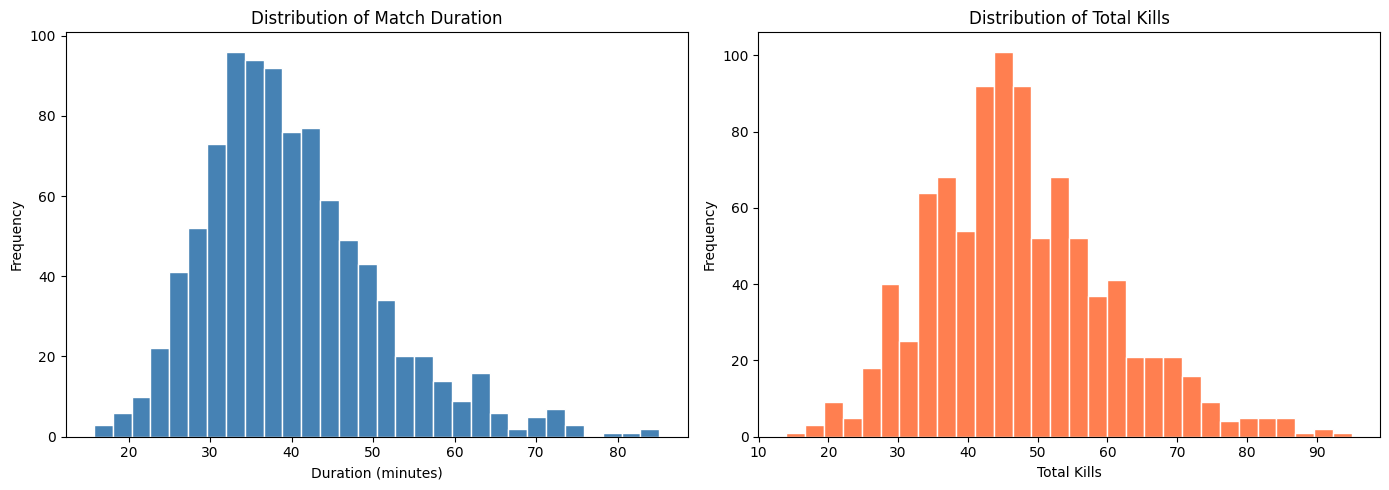

In [57]:
# ============================================================
# 4. EXPLORATORY DATA ANALYSIS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of match duration
axes[0].hist(df["duration"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of Match Duration")
axes[0].set_xlabel("Duration (minutes)")
axes[0].set_ylabel("Frequency")

# Distribution of total kills
axes[1].hist(df["total_kills"], bins=30, color="coral", edgecolor="white")
axes[1].set_title("Distribution of Total Kills")
axes[1].set_xlabel("Total Kills")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

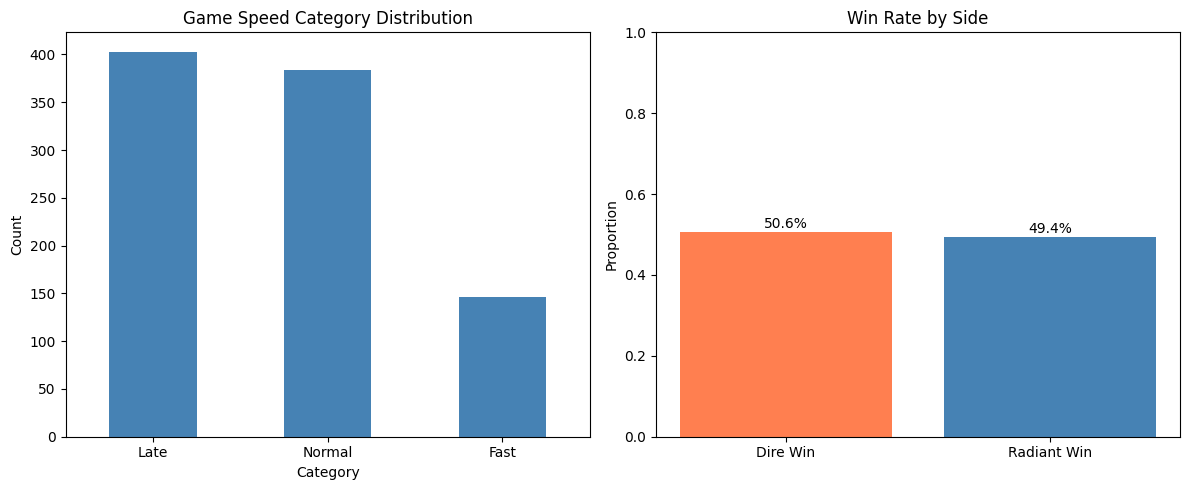


Radiant win rate:
radiant_win
False    0.505895
True     0.494105
Name: proportion, dtype: float64


In [ ]:
# Game speed category distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df["game_speed_categorize"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Game Speed Category Distribution")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Count")
axes[0].tick_params(rotation=0)

# Radiant win rate
win_counts = df["radiant_win"].value_counts(normalize=True)
axes[1].bar(["Dire Win", "Radiant Win"], win_counts.values, color=["coral", "steelblue"])
axes[1].set_title("Win Rate by Side")
axes[1].set_ylabel("Proportion")
axes[1].set_ylim(0, 1)
for i, v in enumerate(win_counts.values):
    axes[1].text(i, v + 0.01, f"{v:.1%}", ha="center")

plt.tight_layout()
plt.show()

print("\nRadiant win rate:")
print(df["radiant_win"].value_counts(normalize=True))

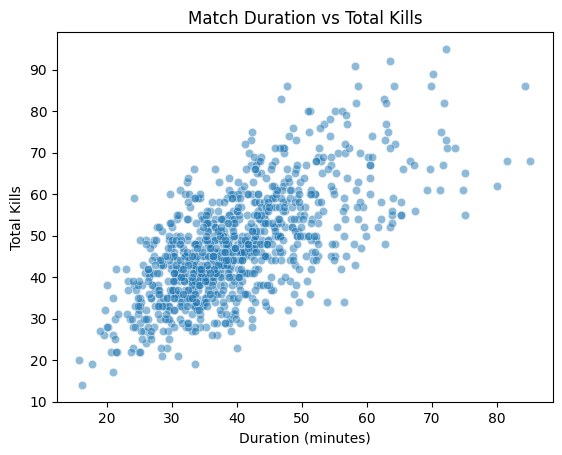


Korelasi durasi vs total kills: 0.672


In [59]:
# Korelasi durasi vs total kills
sns.scatterplot(data=df, x="duration", y="total_kills", alpha=0.5)
plt.title("Match Duration vs Total Kills")
plt.xlabel("Duration (minutes)")
plt.ylabel("Total Kills")
plt.show()

print(f"\nKorelasi durasi vs total kills: {df['duration'].corr(df['total_kills']):.3f}")

In [65]:
# ============================================================
# 5. TEAM ANALYSIS
# ============================================================


radiant = df[["match_id", "radiant_team_name", "radiant_win", 
        "duration", "radiant_score"]].copy()
radiant.columns = ["match_id", "team_name", "win", "duration", "kills"]

dire = df[["match_id", "dire_team_name", "radiant_win", 
        "duration", "dire_score"]].copy()
dire.columns = ["match_id", "team_name", "radiant_win", "duration", "kills"]
dire["win"] = ~dire["radiant_win"]
dire = dire[["match_id", "team_name", "win", "duration", "kills"]]

teams_result = pd.concat([radiant, dire], ignore_index=True)

# Exclude tim yang data-nya tidak lengkap / bukan tim resmi
EXCLUDED_TEAMS = ["Team Somnus", "Team Quinn"]
teams_result = teams_result[~teams_result["team_name"].isin(EXCLUDED_TEAMS)]

print(f"Total team-match records: {len(teams_result)}")
print(f"Unique teams: {teams_result['team_name'].nunique()}")

Total team-match records: 1864
Unique teams: 32


In [69]:
# Hitung statistik per tim
wins_only = teams_result[teams_result["win"] == True]
losses_only = teams_result[teams_result["win"] == False]

# Agregasi utama
team_stats = teams_result.groupby("team_name").agg(
    total_wins=("win", "sum"),
    total_matches=("win", "count"),
    avg_duration=("duration", "mean"),
    avg_kills=("kills", "mean")
).reset_index()

# Rata-rata durasi & kills saat menang vs kalah
avg_win_dur  = wins_only.groupby("team_name")["duration"].mean().rename("avg_win_duration")
avg_lose_dur = losses_only.groupby("team_name")["duration"].mean().rename("avg_lose_duration")
avg_kills  = wins_only.groupby("team_name")["kills"].mean().rename("avg_kills_win")
avg_lose_kills = losses_only.groupby("team_name")["kills"].mean().rename("avg_kills_lose")

# Gabungkan semua
team_stats = (team_stats
    .join(avg_win_dur, on="team_name")
    .join(avg_lose_dur, on="team_name")
    .join(avg_win_kills, on="team_name")
    .join(avg_lose_kills, on="team_name")
)
team_stats["winrate"] = team_stats["total_wins"] / team_stats["total_matches"]

print("Top 10 teams by win rate (min 20 matches):")
(team_stats[team_stats["total_matches"] >= 20]
    .sort_values("winrate", ascending=False)
    .head(10))

Top 10 teams by win rate (min 20 matches):


,team_name,total_wins,total_matches,avg_duration,avg_kills,avg_win_duration,avg_lose_duration,avg_kills_win,avg_kills_lose,winrate
26,Tundra Esports,92,140,40.091857,27.007143,38.695000,42.769167,48.391304,17.208333,0.657143
19,Team Falcons,76,123,41.621951,25.926829,41.356316,42.051489,47.184211,17.425532,0.617886
20,Team Liquid,82,134,39.899627,26.985075,38.585488,41.971923,48.792683,18.346154,0.611940
22,Team Spirit,62,107,40.273738,25.560748,38.488871,42.732889,46.129032,16.888889,0.579439
11,PARIVISION,49,87,42.245632,24.206897,40.111429,44.997632,44.653061,16.736842,0.563218
2,Aurora Gaming,48,88,40.815909,24.318182,42.336042,38.991750,48.729167,14.925000,0.545455
24,Team Yandex,57,105,40.139524,24.961905,38.868596,41.648750,46.403509,16.625000,0.542857
7,MOUZ,79,146,37.005068,23.239726,35.960506,38.236716,46.721519,15.507463,0.541096
10,OG,45,84,40.431548,24.452381,38.762667,42.357179,46.577778,15.102564,0.535714
8,Natus Vincere,45,89,41.966742,22.629213,42.048889,41.882727,46.888889,16.181818,0.505618


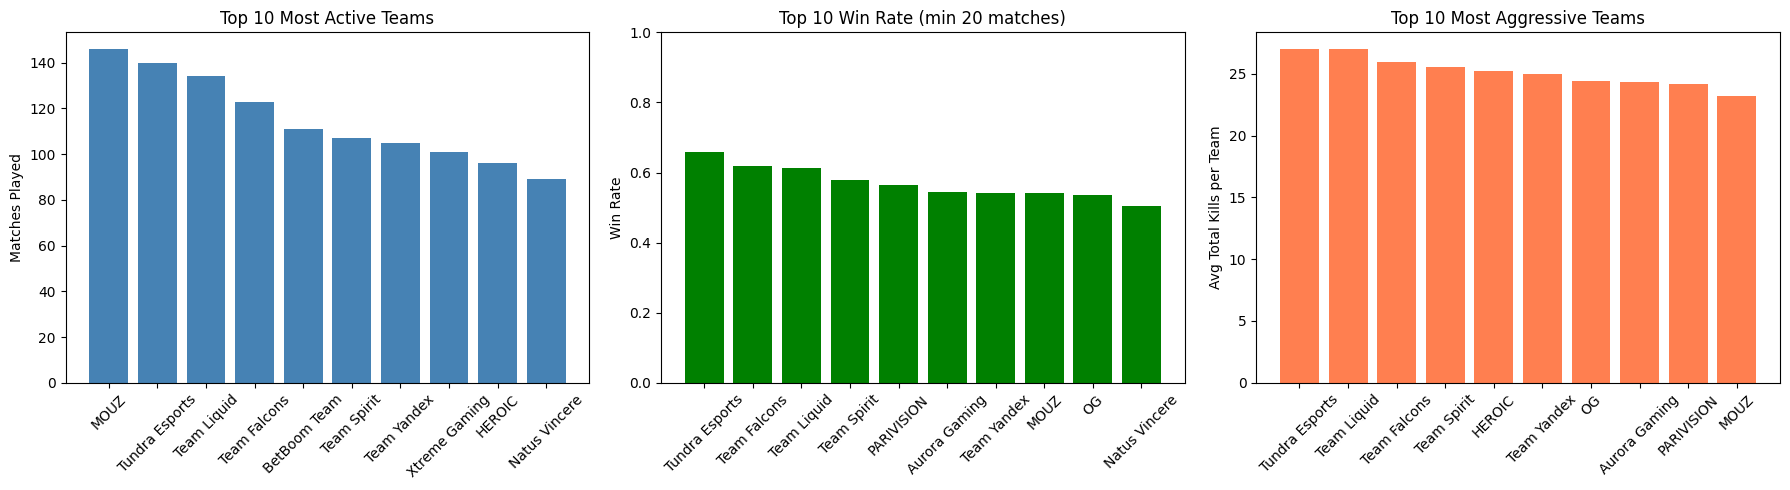

In [70]:
# ============================================================
# 6. VISUALIZATIONS: TEAM RANKINGS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Top 10 most active teams
top_active = (team_stats
    .sort_values("total_matches", ascending=False)
    .head(10))
axes[0].bar(top_active["team_name"], top_active["total_matches"], color="steelblue")
axes[0].set_title("Top 10 Most Active Teams")
axes[0].set_ylabel("Matches Played")
axes[0].tick_params(axis="x", rotation=45)

# Top 10 by win rate (min 20 matches)
top_winrate = (team_stats[team_stats["total_matches"] >= 20]
    .sort_values("winrate", ascending=False)
    .head(10))
axes[1].bar(top_winrate["team_name"], top_winrate["winrate"], color="green")
axes[1].set_title("Top 10 Win Rate (min 20 matches)")
axes[1].set_ylabel("Win Rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

# Top 10 most aggressive teams (avg kills per game)
top_kills = (team_stats[team_stats["total_matches"] >= 20]
            .sort_values("avg_kills", ascending=False)
            .head(10))
axes[2].bar(top_kills["team_name"], top_kills["avg_kills"], color="coral")
axes[2].set_title("Top 10 Most Aggressive Teams")
axes[2].set_ylabel("Avg Total Kills per Team")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [72]:
# ============================================================
# 7. THROW & COMEBACK ANALYSIS
# ============================================================

# throw   : nilai net worth advantage saat tim yg unggul akhirnya kalah
# comeback: nilai net worth disadvantage saat tim yg tertinggal berhasil menang
# NaN di throw  = tidak ada throw di match tersebut
# NaN di comeback = tidak ada comeback di match tersebut

throw_matches    = df[df["throw"].notna()].copy()
comeback_matches = df[df["comeback"].notna()].copy()

print(f"Total matches dengan throw   : {len(throw_matches)} ({len(throw_matches)/len(df):.1%})")
print(f"Total matches dengan comeback: {len(comeback_matches)} ({len(comeback_matches)/len(df):.1%})")

KeyError: 'throw'